# Run Multimodal M3Resp Workflow

Edit the file paths and settings in the configuration cell, then run the notebook from top to bottom.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
from typing import Any


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "m3resp").exists():
            return candidate
    raise RuntimeError("Could not find the m3resp repository root. Start Jupyter from the repo or notebooks folder.")


REPO_ROOT = find_repo_root()
ORG_ROOT = REPO_ROOT.parent

for path in [
    REPO_ROOT / "src",
    ORG_ROOT / "eitprocessing",
]:
    if path.exists() and str(path) not in sys.path:
        sys.path.insert(0, str(path))

REPO_ROOT

PosixPath('/home/mahyart/Desktop/github_repos/m3resp-org/m3resp')

In [2]:
from m3resp import M3Session
from m3resp.adapters import EITProcessingAdapter, ReSurfEMGAdapter

## Configuration

In [3]:
EIT_FILE = Path("/home/mahyart/Desktop/github_repos/m3resp-org/m3resp/data/source/draeger_synthetic_draeger_20Hz.bin")
EMG_FILE = REPO_ROOT / "data" / "source" / "emg_data_synth_quiet_breathing.Poly5"
EIT_VENDOR = "draeger"  # supported: "draeger", "timpel", "sentec", "simulated"

EIT_SUBJECT_TYPE = "adult"
EIT_WELCH_WINDOW_SECONDS = 30.0
EIT_FILTER_MODE = "mdn"  # supported: "mdn", "lowpass", "bandpass", "none"
EIT_LOWPASS_HZ = 1.0
EIT_HIGHPASS_HZ = 0.05
EIT_FILTER_ORDER = 4
EIT_BREATH_MIN_DURATION_SECONDS = 2 / 3
EIT_COMPUTE_PIXEL_TIV = True

EMG_CHANNEL = 0
EMG_HIGH_PASS_HZ = 80
EMG_LOW_PASS_HZ = None
EMG_ENVELOPE_WINDOW_SECONDS = 0.5
EMG_MIN_BREATH_WIDTH_SECONDS = 1.0
MANUAL_OFFSET_SECONDS = 0.0
OUTPUT_DIR = REPO_ROOT / "output" / "multimodal-summary"

## EITProcessing Helper Functions

In [4]:
def preprocess_eit(
    sequence: Any,
    subject_type: str = EIT_SUBJECT_TYPE,
    welch_window_seconds: float = EIT_WELCH_WINDOW_SECONDS,
    filter_mode: str = EIT_FILTER_MODE,
    lowpass_hz: float = EIT_LOWPASS_HZ,
    highpass_hz: float = EIT_HIGHPASS_HZ,
    filter_order: int = EIT_FILTER_ORDER,
    breath_min_duration_seconds: float = EIT_BREATH_MIN_DURATION_SECONDS,
    compute_pixel_tiv: bool = EIT_COMPUTE_PIXEL_TIV,
) -> dict[str, Any]:
    """Run EIT rate detection, filtering, breath detection, TIV, and EELI."""

    import copy

    import numpy as np
    from eitprocessing.features.breath_detection import BreathDetection
    from eitprocessing.features.rate_detection import RateDetection
    from eitprocessing.filters.butterworth_filters import ButterworthFilter
    from eitprocessing.filters.mdn import MDNFilter
    from eitprocessing.parameters.eeli import EELI
    from eitprocessing.parameters.tidal_impedance_variation import TIV

    if not hasattr(sequence, "eit_data") or not hasattr(sequence, "continuous_data"):
        raise TypeError("preprocess_eit expects an eitprocessing Sequence loaded from EIT data.")
    if "raw" not in sequence.eit_data:
        raise KeyError("preprocess_eit requires sequence.eit_data['raw'].")
    if "global_impedance_(raw)" not in sequence.continuous_data:
        raise KeyError("preprocess_eit requires sequence.continuous_data['global_impedance_(raw)'].")

    raw_eit = sequence.eit_data["raw"]
    raw_global_impedance = sequence.continuous_data["global_impedance_(raw)"]

    rate_detector = RateDetection(subject_type, welch_window=welch_window_seconds)
    rate_captures: dict[str, Any] = {}
    respiratory_rate_hz, heart_rate_hz = rate_detector.apply(
        raw_eit,
        captures=rate_captures,
        suppress_length_warnings=True,
        suppress_edge_case_warning=True,
    )

    filter_captures: dict[str, Any] = {}
    filtered_eit = raw_eit
    filtered_global_impedance = raw_global_impedance
    filter_mode = filter_mode.lower()

    if filter_mode == "mdn":
        eit_filter = MDNFilter(
            respiratory_rate=respiratory_rate_hz,
            heart_rate=heart_rate_hz,
        )
        filtered_eit = eit_filter.apply(
            raw_eit,
            captures=filter_captures,
            label="mdn_filtered",
            name="MDN-filtered EIT data",
            description="EIT data filtered with MDN heart-rate noise removal.",
        )
    elif filter_mode in {"lowpass", "bandpass"}:
        cutoff_frequency = lowpass_hz if filter_mode == "lowpass" else (highpass_hz, lowpass_hz)
        eit_filter = ButterworthFilter(
            filter_type=filter_mode,
            cutoff_frequency=cutoff_frequency,
            order=filter_order,
            sample_frequency=raw_eit.sample_frequency,
        )
        filtered_pixels = eit_filter.apply(
            np.nan_to_num(raw_eit.pixel_impedance),
            axis=0,
            captures=filter_captures,
        )
        filtered_eit = copy.deepcopy(raw_eit)
        filtered_eit.label = f"{filter_mode}_filtered"
        filtered_eit.name = f"{filter_mode.title()}-filtered EIT data"
        filtered_eit.description = f"EIT data filtered with a {filter_mode} Butterworth filter."
        filtered_eit.pixel_impedance = filtered_pixels
    elif filter_mode != "none":
        raise ValueError("EIT_FILTER_MODE must be one of: 'mdn', 'lowpass', 'bandpass', 'none'.")

    if filtered_eit is not raw_eit:
        sequence.eit_data.add(filtered_eit, overwrite=True)
        filtered_global_impedance = filtered_eit.get_summed_impedance(
            return_label=f"global_impedance_({filtered_eit.label})",
            name=f"Global impedance ({filtered_eit.label})",
            description="Global impedance calculated from filtered EIT data.",
        )
        sequence.continuous_data.add(filtered_global_impedance, overwrite=True)

    breath_detector = BreathDetection(minimum_duration=breath_min_duration_seconds)
    breath_intervals = breath_detector.find_breaths(
        filtered_global_impedance,
        result_label="eit_breaths",
        store=False,
    )
    sequence.interval_data.add(breath_intervals, overwrite=True)

    tiv_calculator = TIV(breath_detection=breath_detector)
    continuous_tiv = tiv_calculator.compute_parameter(
        filtered_global_impedance,
        sequence=sequence,
        store=False,
        result_label="continuous_tivs",
    )
    sequence.sparse_data.add(continuous_tiv, overwrite=True)

    eeli = EELI(breath_detection=breath_detector).compute_parameter(
        filtered_global_impedance,
        sequence=sequence,
        store=False,
        result_label="continuous_eelis",
    )
    sequence.sparse_data.add(eeli, overwrite=True)

    pixel_tiv = None
    if compute_pixel_tiv:
        pixel_tiv = tiv_calculator.compute_parameter(
            filtered_eit,
            filtered_global_impedance,
            sequence,
            tiv_timing="continuous",
            store=False,
            result_label="pixel_tivs",
        )
        sequence.sparse_data.add(pixel_tiv, overwrite=True)

    return {
        "sequence": sequence,
        "raw_eit": raw_eit,
        "raw_global_impedance": raw_global_impedance,
        "filtered_eit": filtered_eit,
        "filtered_global_impedance": filtered_global_impedance,
        "filter_mode": filter_mode,
        "filter_captures": filter_captures,
        "rate_detector": rate_detector,
        "rate_captures": rate_captures,
        "respiratory_rate_hz": respiratory_rate_hz,
        "heart_rate_hz": heart_rate_hz,
        "breath_intervals": breath_intervals,
        "continuous_tiv": continuous_tiv,
        "eeli": eeli,
        "pixel_tiv": pixel_tiv,
    }


def detect_eit_breaths(processed_eit: dict[str, Any], **kwargs: Any) -> list[dict[str, Any]]:
    """Convert EITProcessing breath intervals to M3Resp breath rows."""

    events = []
    for breath in processed_eit["breath_intervals"].values:
        events.append(
            {
                "start_time": breath.start_time,
                "end_time": breath.end_time,
                "peak_time": breath.middle_time,
                "source": "eitprocessing.BreathDetection",
            }
        )
    return events


## ReSurfEMG Helper Functions

In [5]:
def load_emg(path: str, **kwargs: Any) -> dict[str, Any]:
    """Load an EMG file with ReSurfEMG's generic converter."""

    from resurfemg.data_connector.converter_functions import load_file

    array, dataframe, metadata = load_file(path, **kwargs)
    return {
        "array": array,
        "dataframe": dataframe,
        "metadata": metadata,
    }


def preprocess_emg(
    recording: dict[str, Any],
    channel: int = EMG_CHANNEL,
    high_pass_hz: float = EMG_HIGH_PASS_HZ,
    low_pass_hz: float | None = EMG_LOW_PASS_HZ,
    envelope_window_seconds: float = EMG_ENVELOPE_WINDOW_SECONDS,
) -> dict[str, Any]:
    """Band-pass one EMG channel and compute an ARV envelope."""

    import numpy as np
    from resurfemg.preprocessing.envelope import full_rolling_arv
    from resurfemg.preprocessing.filtering import emg_bandpass_butter

    if not isinstance(recording, dict) or "array" not in recording or "metadata" not in recording:
        raise TypeError("preprocess_emg expects a ReSurfEMG-loaded EMG recording dictionary.")

    metadata = dict(recording["metadata"])
    fs = float(metadata["fs"])
    array = recording["array"]
    raw = np.asarray(array[channel], dtype=float)

    if low_pass_hz is None:
        low_pass_hz = min(fs / 2 * 0.95, 500)

    filtered = emg_bandpass_butter(
        emg_raw=raw,
        high_pass=high_pass_hz,
        low_pass=low_pass_hz,
        fs_emg=fs,
    )
    envelope_window_samples = max(1, int(envelope_window_seconds * fs))
    envelope = full_rolling_arv(filtered, envelope_window_samples)

    return {
        **recording,
        "channel": channel,
        "fs": fs,
        "raw_channel": raw,
        "filtered": filtered,
        "envelope": envelope,
        "filter": {
            "high_pass_hz": high_pass_hz,
            "low_pass_hz": low_pass_hz,
            "envelope_window_seconds": envelope_window_seconds,
        },
    }


def detect_emg_breaths(
    processed_emg: dict[str, Any],
    min_breath_width_seconds: float = EMG_MIN_BREATH_WIDTH_SECONDS,
    half_window_seconds: float = 0.5,
    **kwargs: Any,
) -> list[dict[str, Any]]:
    """Detect EMG breath peaks and convert them to M3Resp breath rows."""

    from resurfemg.postprocessing.event_detection import detect_emg_breaths

    fs = float(processed_emg["fs"])
    envelope = processed_emg["envelope"]
    min_width_samples = max(1, int(min_breath_width_seconds * fs))
    half_window_samples = max(1, int(half_window_seconds * fs))

    peak_indices = detect_emg_breaths(
        emg_env=envelope,
        min_peak_width_s=min_width_samples,
        **kwargs,
    )

    events = []
    for peak_index in peak_indices:
        start_index = max(0, int(peak_index) - half_window_samples)
        end_index = min(len(envelope) - 1, int(peak_index) + half_window_samples)
        events.append(
            {
                "start_time": start_index / fs,
                "end_time": end_index / fs,
                "peak_time": int(peak_index) / fs,
                "source": "resurfemg.detect_emg_breaths",
                "metadata": {
                    "start_index": start_index,
                    "peak_index": int(peak_index),
                    "end_index": end_index,
                    "channel": processed_emg["channel"],
                },
            }
        )

    return events

## Run Workflow

In [6]:
session = M3Session(
    eit_adapter=EITProcessingAdapter(),
    emg_adapter=ReSurfEMGAdapter(loader=load_emg),
)

session.load_eit(EIT_FILE, vendor=EIT_VENDOR)
session.load_emg(EMG_FILE, verbose=False)

session.preprocess_eit(preprocess=preprocess_eit)
session.preprocess_emg(preprocess=preprocess_emg)
session.detect_eit_breaths(detector=detect_eit_breaths)
session.detect_emg_breaths(detector=detect_emg_breaths)

session.align_modalities(
    method="manual_offset",
    offset_seconds=MANUAL_OFFSET_SECONDS,
)
session.export_summary(OUTPUT_DIR)

session

## EIT Processing Summary

In [7]:
eit = session.processed["eit"]
eit_summary = {
    "filter_mode": eit["filter_mode"],
    "respiratory_rate_bpm": float(eit["respiratory_rate_hz"] * 60),
    "heart_rate_bpm": float(eit["heart_rate_hz"] * 60),
    "n_eit_breaths": len(session.events["eit_breaths"]),
    "n_continuous_tiv_values": len(eit["continuous_tiv"]),
    "n_eeli_values": len(eit["eeli"]),
    "pixel_tiv_shape_per_breath": None
    if eit["pixel_tiv"] is None or len(eit["pixel_tiv"].values) == 0
    else eit["pixel_tiv"].values[0].shape,
}
eit_summary


{'filter_mode': 'mdn',
 'respiratory_rate_bpm': 13.88224396109581,
 'heart_rate_bpm': 95.52607929706575,
 'n_eit_breaths': 12,
 'n_continuous_tiv_values': 12,
 'n_eeli_values': 12,
 'pixel_tiv_shape_per_breath': (32, 32)}

## Visualize Output

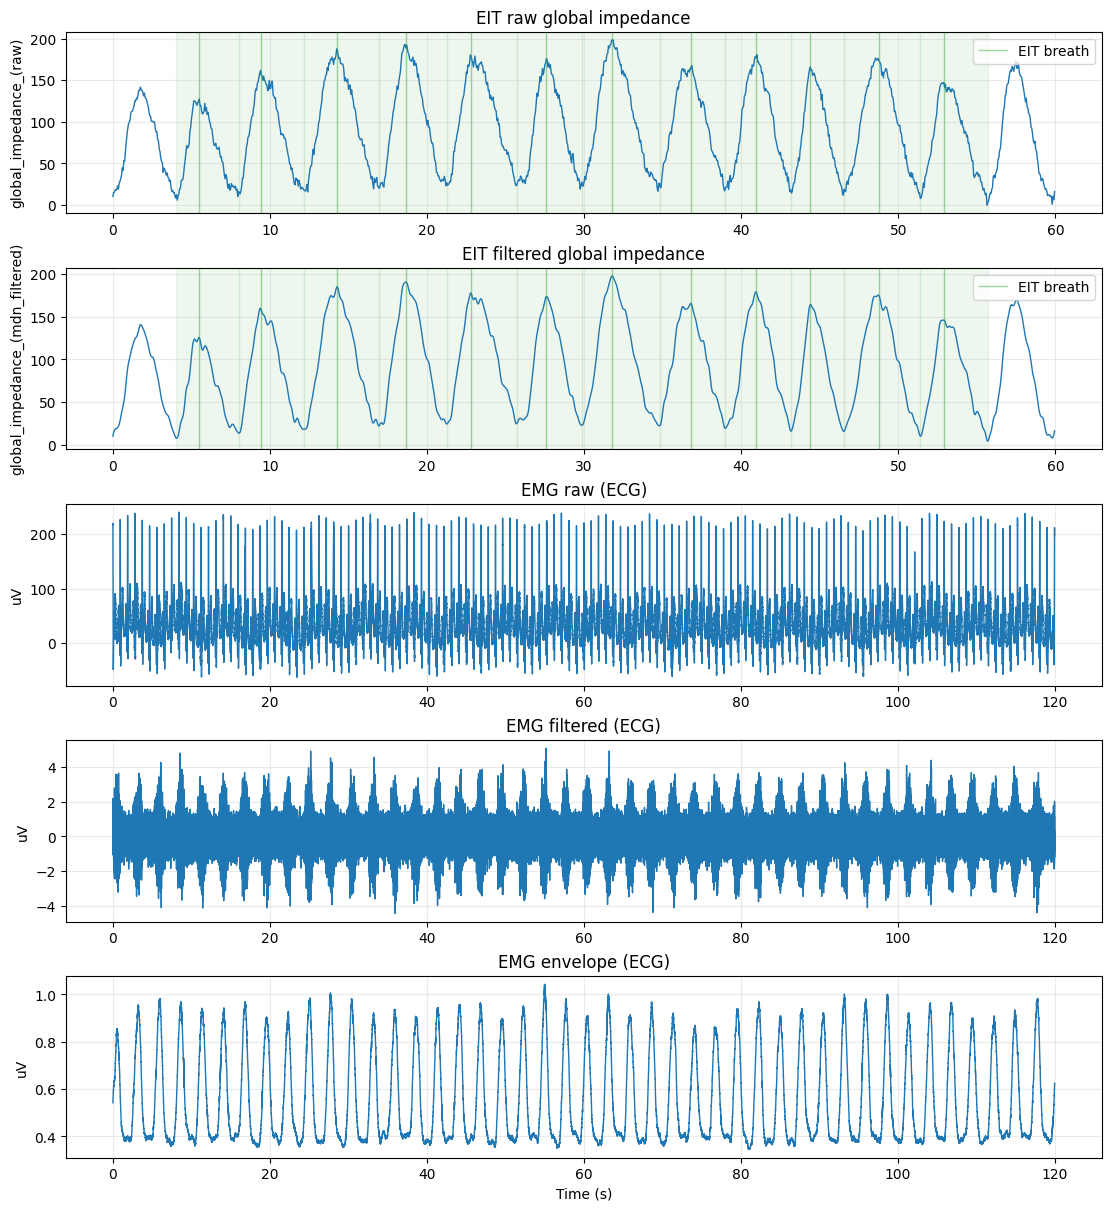

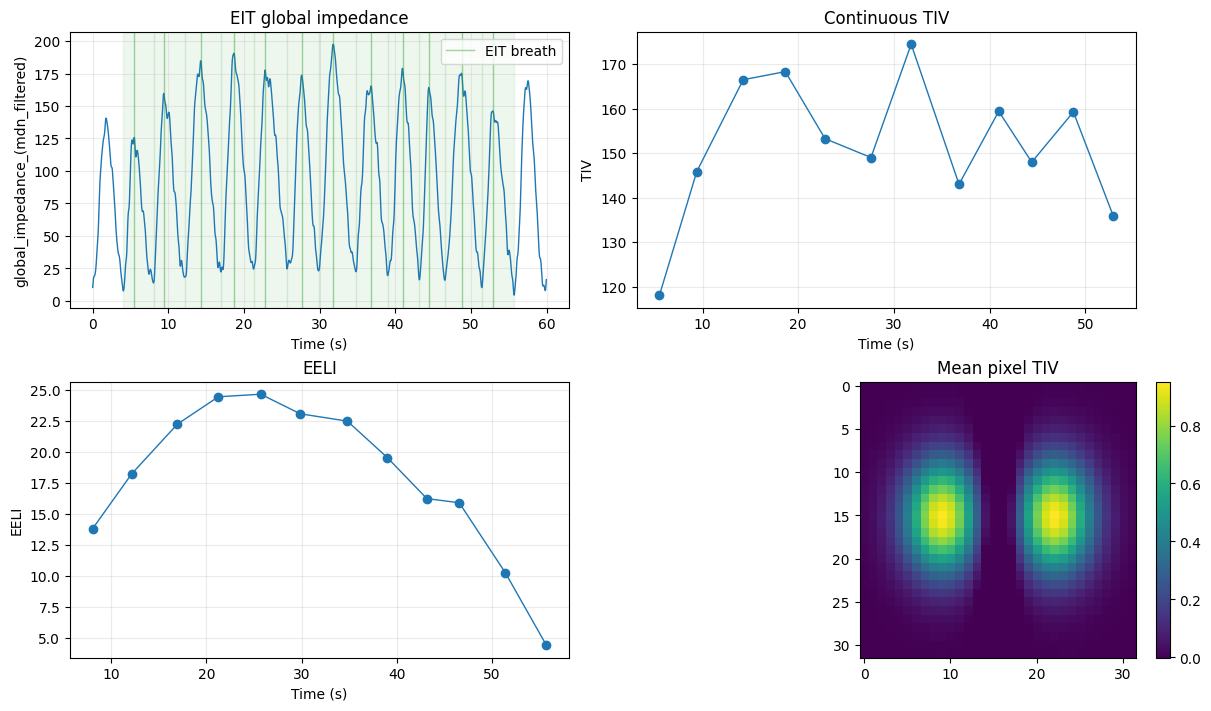

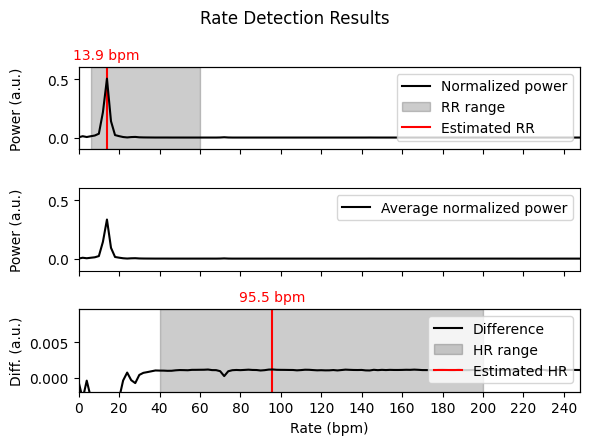

In [8]:
from m3resp.visualization.session import plot_eit_processing_summary, plot_session_overview

fig = plot_session_overview(session, max_seconds=120)
fig.savefig(OUTPUT_DIR / "overview.png", dpi=150)

eit_fig = plot_eit_processing_summary(session)
eit_fig.savefig(OUTPUT_DIR / "eit-processing.png", dpi=150)

rate_fig = session.processed["eit"]["rate_detector"].plotting.plot(
    **session.processed["eit"]["rate_captures"]
)
rate_fig.savefig(OUTPUT_DIR / "eit-rate-detection.png", dpi=150)
